# Harminv cavity eigenmode simulation

Notebook version of `harminv_cavity.py`.

In [18]:
from pathlib import Path
import sys

notebook_dir = Path.cwd()
if not (notebook_dir / "geometry.py").exists():
    notebook_dir = Path("cavity/eigenmode").resolve()
if str(notebook_dir) not in sys.path:
    sys.path.insert(0, str(notebook_dir))

import geometry
import parse_to_meep
import numpy as np
import pandas as pd
import meep as mp
import matplotlib.pyplot as plt

fs = 18
plt.rcParams.update({
    'font.family': 'Arial',
    'font.sans-serif': ['Arial'],
    'font.size': fs,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
})

# Keep notebook output focused on plots and result tables.
mp.verbosity(0)

def harminv_modes_to_dataframe(modes):
    rows = []
    for mode in modes:
        q_value = getattr(mode, "q", getattr(mode, "Q", np.nan))
        rows.append({
            "frequency": getattr(mode, "freq", np.nan),
            "Q": q_value,
            "decay": getattr(mode, "decay", np.nan),
            "amplitude": getattr(mode, "amp", getattr(mode, "amplitude", np.nan)),
        })
    df_modes = pd.DataFrame(rows, columns=["frequency", "Q", "decay", "amplitude"])
    if df_modes.empty:
        return df_modes
    return df_modes.sort_values("Q", ascending=False).reset_index(drop=True)

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.size"] = 15
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"

## Geometry and simulation settings

`resolution` と `sqrt(3)` を含むセルサイズの組み合わせによって、Meep が格子点数を丸める警告を出すことがあります。計算は続行されます。

In [13]:
# Geometry settings
a = 1 # 0.4
nx = 8 # 14
ny = 30 # 50
offset_x = 0
offset_y = 0
n_cavity = 5 # 3
barrier = 4
wgi = 0 # 1.1
holeshift = 0.2
hslab = 0
hall = 0

eps_r = 2.6**2
fcen = 0.25
df = 0.05
resolution = 16
pml_buffer = 4
t_after_sources = 3000

## Build the Meep simulation

In [14]:
# 2D cavity geometry
cell = mp.Vector3(ny + pml_buffer, (nx + pml_buffer / 2) * np.sqrt(3), hall)
blk = mp.Block(
    size=mp.Vector3(ny + pml_buffer, (nx + pml_buffer / 2) * np.sqrt(3), mp.inf),
    material=mp.Medium(epsilon=eps_r),
)
ld = geometry.line_defect(a, nx, ny, offset_x, offset_y, n_cavity, barrier, wgi, holeshift)
arr_obj = parse_to_meep.parse_geometry(ld)
arr_geometry = [blk] + arr_obj

src = [
    mp.Source(mp.GaussianSource(fcen, fwidth=df), mp.Hz, mp.Vector3(0.5), amplitude=1),
    mp.Source(mp.GaussianSource(fcen, fwidth=df), mp.Hz, mp.Vector3(-0.5), amplitude=-1),
]

# Alternative single-source setup:
# src = [mp.Source(mp.GaussianSource(fcen, fwidth=df), mp.Hz, mp.Vector3(0), amplitude=1)]

# sym = [mp.Mirror(mp.Y, phase=-1), mp.Mirror(mp.X, phase=-1)]
# sym = [mp.Mirror(mp.Y, phase=-1), mp.Mirror(mp.X, phase=1)]
sym = [mp.Mirror(mp.Y, phase=-1)]
# sym = []

pml_layers = [mp.PML(1.0)]

sim = mp.Simulation(
    cell_size=cell,
    geometry=arr_geometry,
    boundary_layers=pml_layers,
    sources=src,
    symmetries=sym,
    resolution=resolution,
)

## Check the geometry

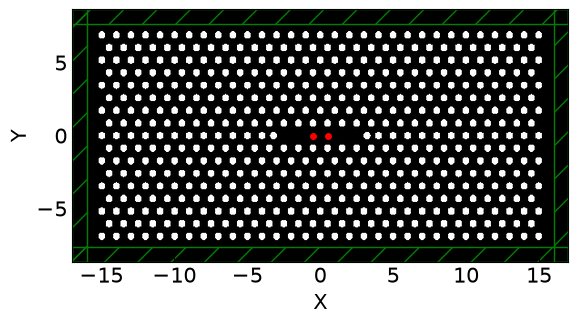

In [15]:
fig = plt.figure(dpi=100)
sim.plot2D(ax=fig.gca())
plt.show()

## Get eigenmodes with Harminv

In [16]:
h = mp.Harminv(mp.Hz, mp.Vector3(), fcen, df)
sim.reset_meep()
sim.run(mp.after_sources(h), until_after_sources=t_after_sources)

df_results = harminv_modes_to_dataframe(h.modes)
display(df_results)

# Negative-Q modes are usually numerical/fit artifacts, so this view is often the useful one.
display(df_results[df_results["Q"] > 0])
print("Done")

,frequency,Q,decay,amplitude
0,0.228983,23804.244635,-0.000005,5.363494e-19+2.697448e-18j
1,0.274645,3316.524962,-0.000041,4.278550e-19-3.868355e-18j
2,0.225933,2922.002463,-0.000039,-3.466825e-18-2.221616e-18j
3,0.267138,550.038797,-0.000243,1.623941e-18+9.522596e-19j
4,0.233094,526.394460,-0.000221,2.109568e-17+2.234480e-17j
5,0.273353,66.027321,-0.002070,-2.379026e-18+1.941195e-17j
6,0.225294,-425.350844,0.000265,-2.666274e-20+5.211723e-20j
7,0.259663,-608.221753,0.000213,1.144434e-20+1.209037e-20j
8,0.273979,-622.611139,0.000220,-7.298442e-20-7.440215e-20j
9,0.238823,-1636.334497,0.000073,-9.587785e-19-7.076481e-19j


,frequency,Q,decay,amplitude
0,0.228983,23804.244635,-0.000005,5.363494e-19+2.697448e-18j
1,0.274645,3316.524962,-0.000041,4.278550e-19-3.868355e-18j
2,0.225933,2922.002463,-0.000039,-3.466825e-18-2.221616e-18j
3,0.267138,550.038797,-0.000243,1.623941e-18+9.522596e-19j
4,0.233094,526.394460,-0.000221,2.109568e-17+2.234480e-17j
5,0.273353,66.027321,-0.002070,-2.379026e-18+1.941195e-17j


Done


## Field distributions of eigenmodes

Run the simulation again with a narrow-band source to see the mode.

/opt/miniconda3/envs/pmp/lib/python3.13/site-packages/meep/simulation.py:1173: RuntimeWarning: Harminv frequency 0.279542 is outside maximum Source frequency 0.275
  warnings.warn(warn_fmt.format(harminv_max, sf_max), RuntimeWarning)


,frequency,Q,decay,amplitude
0,0.276020,16898.917005,-0.000008,4.569191e-18-2.074879e-18j
1,0.276517,8594.512231,-0.000016,-2.064138e-17+1.720054e-17j
2,0.270123,5571.053600,-0.000024,-3.445253e-19+1.073483e-18j
3,0.274986,809.292259,-0.000170,2.125458e-18+3.382906e-18j
4,0.278981,146.684739,-0.000951,3.679276e-18+7.420220e-18j
5,0.269721,-130.930731,0.001030,6.204362e-19-6.373977e-19j
6,0.277524,-202.642963,0.000685,7.273537e-19-4.783624e-21j
7,0.278812,-1034.883363,0.000135,4.698907e-20+5.236769e-19j
8,0.276948,-1534.599713,0.000090,-1.516042e-18+1.392574e-17j
9,0.279531,-6436.210075,0.000022,-2.413148e-18-1.138717e-18j


,frequency,Q,decay,amplitude
0,0.276020,16898.917005,-0.000008,4.569191e-18-2.074879e-18j
1,0.276517,8594.512231,-0.000016,-2.064138e-17+1.720054e-17j
2,0.270123,5571.053600,-0.000024,-3.445253e-19+1.073483e-18j
3,0.274986,809.292259,-0.000170,2.125458e-18+3.382906e-18j
4,0.278981,146.684739,-0.000951,3.679276e-18+7.420220e-18j


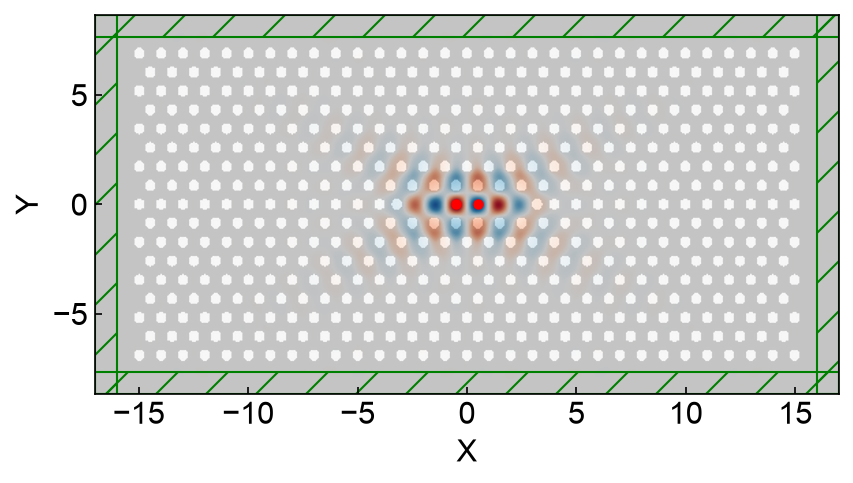

Done


In [19]:
fcen_cavity = 0.274542 # 0.27111168664110774 # 0.27685639922705274
df_cavity = 0.01

sim.reset_meep()
h_cavity = mp.Harminv(mp.Hz, mp.Vector3(), fcen_cavity, df_cavity)
sim.run(mp.after_sources(h_cavity), until_after_sources=t_after_sources)

df_cavity_results = harminv_modes_to_dataframe(h_cavity.modes)
display(df_cavity_results)

# Negative-Q modes are usually numerical/fit artifacts, so this view is often the useful one.
display(df_cavity_results[df_cavity_results["Q"] > 0])

fig = plt.figure(dpi=150)
sim.plot2D(ax=fig.gca(), fields=mp.Hz)
plt.show()

print("Done")